In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

from utils import parse_latencies, parse_power_log, get_power_index, compute_layer_metrics_by_cycle

In [2]:
DATA_PATH = Path('../raw_data/single_conv_layer')

In [3]:
with open((DATA_PATH/'idling_power.json'), 'r') as fp:
    data = json.load(fp)

avg_power = data['avg_idle_power']
print(f'Average power consumed in IDLE state: {avg_power}')

Average power consumed in IDLE state: 3584831.5854031947


## Single Convolution Layers


### Kernel 1 Stride 3 Output 3

In [4]:
model_name = 'conv_k1_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2906/2906 [00:00<00:00, 227914.65it/s]
Computing layer execution times: 3000it [00:00, 487464.15it/s]


In [5]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s1_o3: 2906
Number of TensorRT layers in conv_k1_s1_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 3.683242 seconds


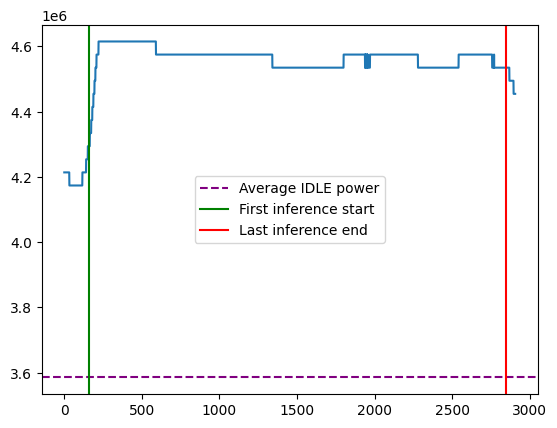

In [6]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [7]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k1 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 1983747.75it/s]


In [8]:
metrics_df_k1.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,1.862000e+03,1.862000e+03,3000.000000
mean,1500.500000,4.564808e+06,9.799763e+05,0.824377
std,866.169729,3.365849e+04,3.365849e+04,0.089393
min,1.000000,4.293696e+06,7.088644e+05,0.377152
25%,750.750000,4.534464e+06,9.496324e+05,0.806904
50%,1500.500000,4.574592e+06,9.897604e+05,0.843168
75%,2250.250000,4.574592e+06,9.897604e+05,0.860688
max,3000.000000,4.614720e+06,1.029888e+06,2.116576


In [9]:
metrics_df_k1.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt    1862
layer_power_excluding_idle_power_micro_watt    1862
layer_run_time                                 3000
dtype: int64

<Axes: >

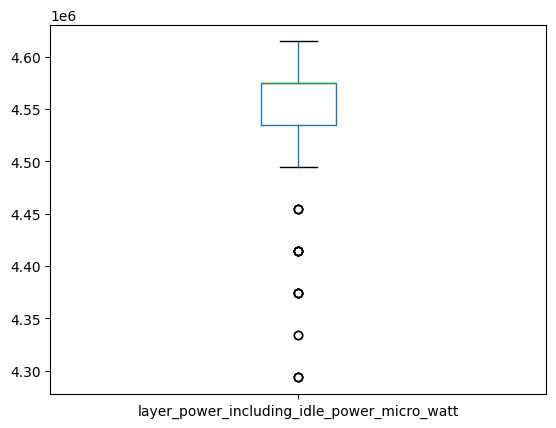

In [10]:
metrics_df_k1.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 2 Stride 1 Output 3

In [11]:
model_name = 'conv_k2_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2245/2245 [00:00<00:00, 206332.99it/s]
Computing layer execution times: 3000it [00:00, 648904.75it/s]


In [12]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k2_s1_o3: 2245
Number of TensorRT layers in conv_k2_s1_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 2.756743 seconds


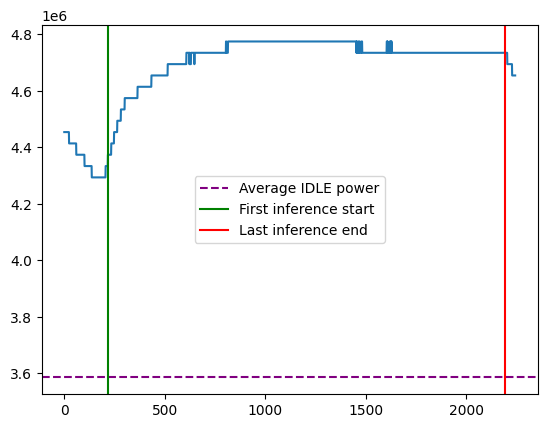

In [13]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [14]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k2 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 2106279.21it/s]


In [15]:
metrics_df_k2.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,1.246000e+03,1.246000e+03,3000.000000
mean,1500.500000,4.720869e+06,1.136038e+06,0.588122
std,866.169729,7.469009e+04,7.469009e+04,0.060683
min,1.000000,4.373952e+06,7.891204e+05,0.458432
25%,750.750000,4.735104e+06,1.150272e+06,0.574360
50%,1500.500000,4.735104e+06,1.150272e+06,0.585792
75%,2250.250000,4.775232e+06,1.190400e+06,0.596264
max,3000.000000,4.775232e+06,1.190400e+06,3.183904


In [16]:
metrics_df_k2.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt    1246
layer_power_excluding_idle_power_micro_watt    1246
layer_run_time                                 3000
dtype: int64

<Axes: >

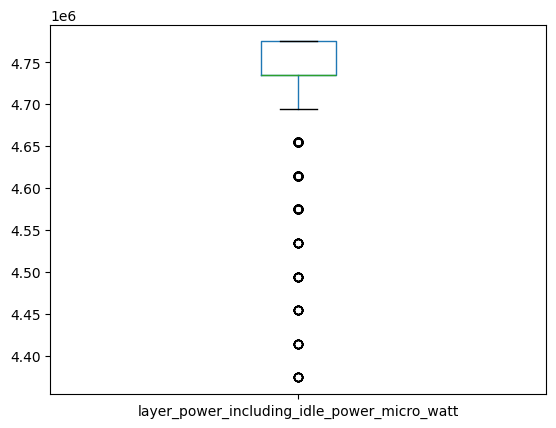

In [17]:
metrics_df_k2.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 3 Stride 1 Output 3

In [18]:
model_name = 'conv_k3_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2957/2957 [00:00<00:00, 170730.64it/s]
Computing layer execution times: 3000it [00:00, 559364.84it/s]


In [19]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k3_s1_o3: 2957
Number of TensorRT layers in conv_k3_s1_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 3.652603 seconds


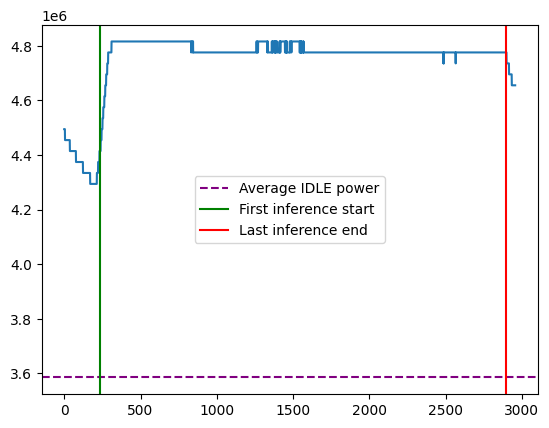

In [20]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [21]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k3 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 1354603.51it/s]


In [22]:
metrics_df_k3.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,1.777000e+03,1.777000e+03,3000.000000
mean,1500.500000,4.783090e+06,1.198259e+06,0.808900
std,866.169729,3.485411e+04,3.485411e+04,0.096463
min,1.000000,4.414080e+06,8.292484e+05,0.371168
25%,750.750000,4.775232e+06,1.190400e+06,0.813824
50%,1500.500000,4.775232e+06,1.190400e+06,0.824544
75%,2250.250000,4.815360e+06,1.230528e+06,0.833864
max,3000.000000,4.815360e+06,1.230528e+06,2.576896


In [23]:
metrics_df_k3.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt    1777
layer_power_excluding_idle_power_micro_watt    1777
layer_run_time                                 3000
dtype: int64

<Axes: >

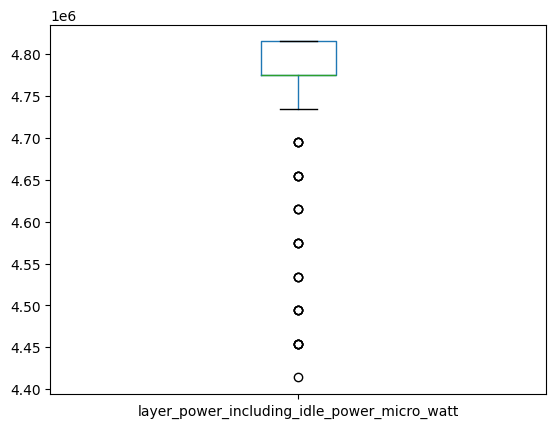

In [24]:
metrics_df_k3.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 4 Stride 1 Output 3

In [25]:
model_name = 'conv_k4_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3572/3572 [00:00<00:00, 171832.25it/s]
Computing layer execution times: 3000it [00:00, 446028.57it/s]


In [26]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k4_s1_o3: 3572
Number of TensorRT layers in conv_k4_s1_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 4.490518 seconds


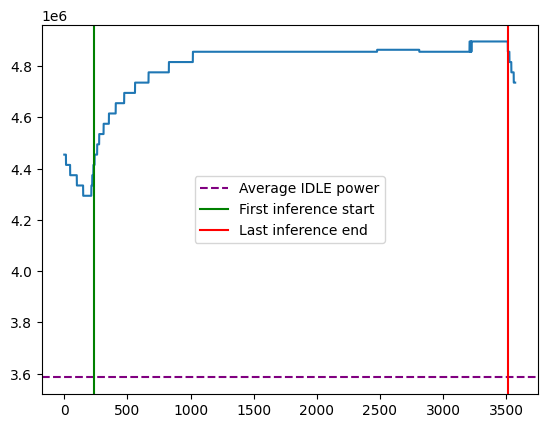

In [27]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [28]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k4 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 1914624.47it/s]


In [29]:
metrics_df_k4.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,2.347000e+03,2.347000e+03,3000.000000
mean,1500.500000,4.826388e+06,1.241557e+06,1.059645
std,866.169729,8.050461e+04,8.050461e+04,0.058352
min,1.000000,4.454208e+06,8.693764e+05,0.887520
25%,750.750000,4.855488e+06,1.270656e+06,1.046016
50%,1500.500000,4.855488e+06,1.270656e+06,1.055776
75%,2250.250000,4.855488e+06,1.270656e+06,1.065064
max,3000.000000,4.895616e+06,1.310784e+06,3.788096


In [30]:
metrics_df_k4.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt    2347
layer_power_excluding_idle_power_micro_watt    2347
layer_run_time                                 3000
dtype: int64

<Axes: >

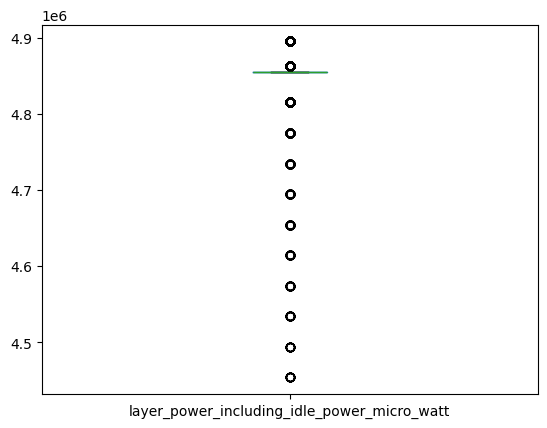

In [31]:
metrics_df_k4.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 5 Stride 1 Output 3

In [32]:
model_name = 'conv_k5_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3392/3392 [00:00<00:00, 211895.37it/s]
Computing layer execution times: 3000it [00:00, 464897.36it/s]


In [33]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k5_s1_o3: 3392
Number of TensorRT layers in conv_k5_s1_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 4.478875 seconds


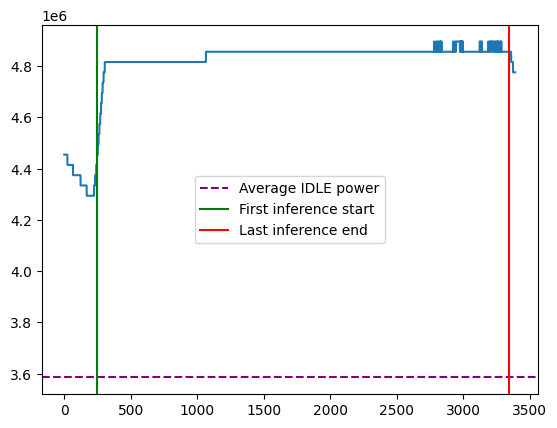

In [34]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [35]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k5 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 1240551.32it/s]


In [36]:
metrics_df_k5.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,2.245000e+03,2.245000e+03,3000.000000
mean,1500.500000,4.843190e+06,1.258359e+06,1.132485
std,866.169729,3.646634e+04,3.646634e+04,0.119010
min,1.000000,4.414080e+06,8.292484e+05,0.447936
25%,750.750000,4.815360e+06,1.230528e+06,1.116096
50%,1500.500000,4.855488e+06,1.270656e+06,1.140656
75%,2250.250000,4.855488e+06,1.270656e+06,1.184256
max,3000.000000,4.895616e+06,1.310784e+06,1.956224


In [37]:
metrics_df_k5.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt    2245
layer_power_excluding_idle_power_micro_watt    2245
layer_run_time                                 3000
dtype: int64

<Axes: >

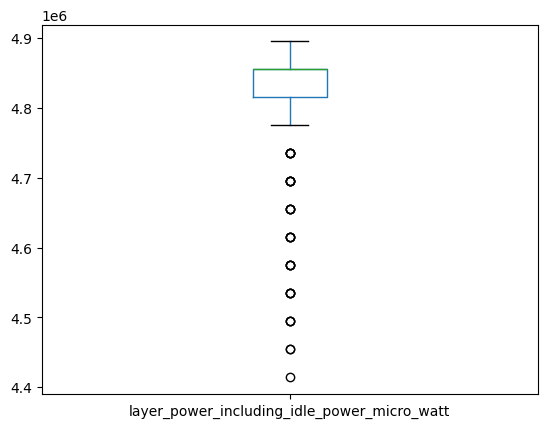

In [38]:
metrics_df_k5.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

## Kernels Plot

Text(0.5, 0, 'Kernel size')

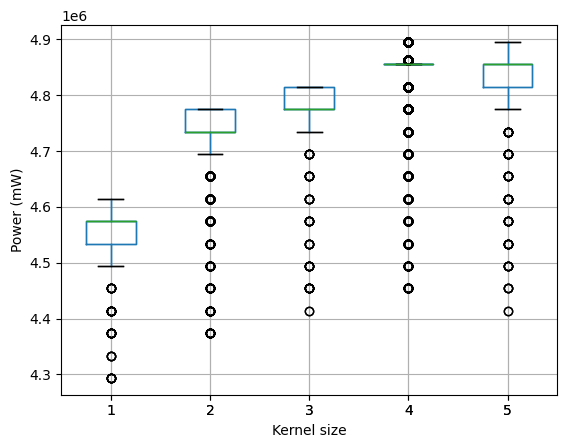

In [43]:
df = pd.concat(
    [
        metrics_df_k1["layer_power_including_idle_power_micro_watt"],
        metrics_df_k2["layer_power_including_idle_power_micro_watt"],
        metrics_df_k3["layer_power_including_idle_power_micro_watt"],
        metrics_df_k4["layer_power_including_idle_power_micro_watt"],
        metrics_df_k5["layer_power_including_idle_power_micro_watt"],
    ],
    axis=1,
)

# set column names (will be displayed as plot labels)
df.columns = ['1', '2', '3', '4', '5']  

# use pandas' boxplot method
df.boxplot().set_ylabel('Power (mW)')
df.boxplot().set_xlabel('Kernel size')